In [1]:
import xarray as xr
import glob
import re
from pathlib import Path
import datetime
from matplotlib import pyplot as plt



In [9]:
files = sorted(glob.glob("/mnt/e/monger/2024/*.nc"))

datasets = [xr.open_dataset(f) for f in files]
ds = xr.concat(datasets, dim="time")

sst = ds['sst']

#creating xarray datasets

/tmp/ipykernel_3113/962031670.py:2: FutureWarning: In a future version, xarray will not decode the variable 'time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  clim = xr.open_dataset("/mnt/e/monger/1991-2020-SST_Normals-Daily_mean-std.nc")


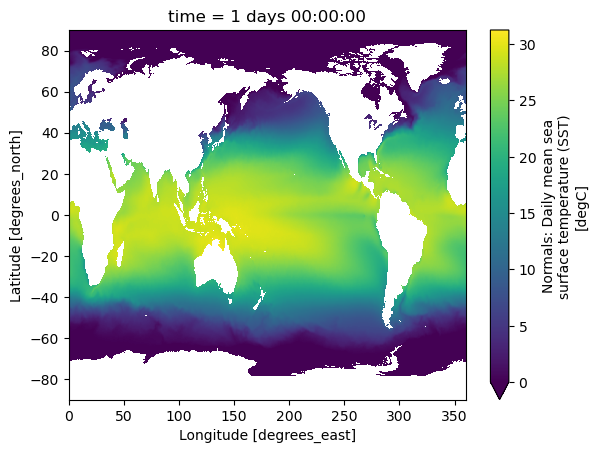

In [10]:
#getting climatology
clim = xr.open_dataset("/mnt/e/monger/1991-2020-SST_Normals-Daily_mean-std.nc")  
clim_sst = clim['norm']
clim_sst.isel(time=0).plot(cmap = 'viridis', vmin=0)


In [ ]:
sst.isel(time=0).plot(cmap = 'viridis', vmin=0)


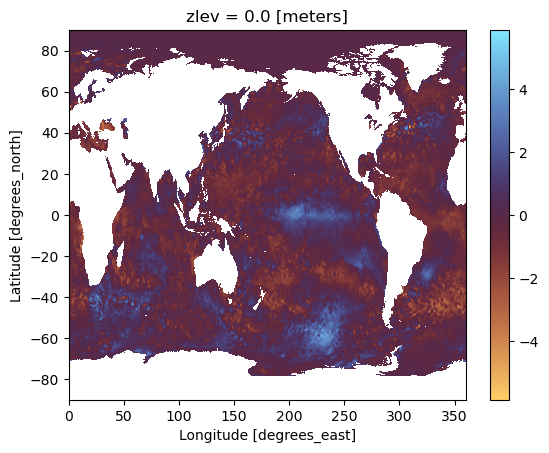

In [4]:
anom_test = sst.isel(time=0) - clim_sst.isel(time=0)
anom_test.plot(cmap = 'managua')


In [ ]:
anom_list = []
for d in range(len(sst.time)):
    anom = sst.isel(time=d) - clim_sst.isel(time=d)
    anom_list.append(anom)




In [ ]:
anom_list[0].plot(cmap = 'RdBu_r')


In [6]:
import numpy as np
from pathlib import Path

# Create output directory for anomaly averages
output_dir = Path("anom_averages")
output_dir.mkdir(exist_ok=True)

# Group every 8 anomalies and average
for i in range(0, len(anom_list), 8):
    group = anom_list[i:i+8]
    if not group:
        continue
    
    arrays = [anom.values[0, :, :] for anom in group]  # Select 2D slice (zlev=0, lat, lon)
    
    # Average the arrays
    avg_arr = np.mean(arrays, axis=0)
    
    # Create DataArray
    coords = {'lat': anom_list[0]['lat'], 'lon': anom_list[0]['lon']}
    avg_da = xr.DataArray(avg_arr, coords=coords, dims=['lat', 'lon'], name='anom')
    
    # Save as new .nc
    output_file = output_dir / f"anom_average_group_{i//8}.nc"
    avg_da.to_netcdf(output_file)
    print(f"Saved {output_file} (averaged {len(group)} anomalies)")


Saved anom_averages/anom_average_group_0.nc (averaged 8 anomalies)
Saved anom_averages/anom_average_group_1.nc (averaged 8 anomalies)
Saved anom_averages/anom_average_group_2.nc (averaged 8 anomalies)
Saved anom_averages/anom_average_group_3.nc (averaged 8 anomalies)
Saved anom_averages/anom_average_group_4.nc (averaged 8 anomalies)
Saved anom_averages/anom_average_group_5.nc (averaged 8 anomalies)
Saved anom_averages/anom_average_group_6.nc (averaged 8 anomalies)
Saved anom_averages/anom_average_group_7.nc (averaged 8 anomalies)
Saved anom_averages/anom_average_group_8.nc (averaged 8 anomalies)
Saved anom_averages/anom_average_group_9.nc (averaged 8 anomalies)
Saved anom_averages/anom_average_group_10.nc (averaged 8 anomalies)
Saved anom_averages/anom_average_group_11.nc (averaged 8 anomalies)
Saved anom_averages/anom_average_group_12.nc (averaged 8 anomalies)
Saved anom_averages/anom_average_group_13.nc (averaged 8 anomalies)
Saved anom_averages/anom_average_group_14.nc (averaged 8 a

In [7]:
import matplotlib.pyplot as plt
import imageio
from pathlib import Path

# Output directories for anomaly timelapse
anom_frames_dir = Path("anom_frames")
anom_frames_dir.mkdir(exist_ok=True)
anom_gif_path = Path("anom_timelapse.gif")

# Collect averaged anomaly files (sorted by group number)
anom_avg_files = sorted(Path("anom_averages").glob("*.nc"))
print(f"Found {len(anom_avg_files)} averaged anomaly files")

anom_frame_paths = []
for i, fn in enumerate(anom_avg_files):
    # Load data
    ds = xr.open_dataset(fn)
    anom = ds['anom']
    
    # Plot
    plt.figure(figsize=(10, 5))
    plt.pcolormesh(ds['lon'], ds['lat'], anom.values, cmap='managua', shading='auto', vmin=-5, vmax=5)  # Adjust vmin/vmax for anomalies
    plt.colorbar(label='Anomaly (°C)')
    plt.title(f'8-Day Average Anomaly - Group {i}')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    
    # Save frame
    frame_path = anom_frames_dir / f"anom_frame_{i:03d}.png"
    plt.savefig(frame_path, dpi=150, bbox_inches='tight')
    plt.close()
    anom_frame_paths.append(frame_path)
    print(f"Saved {frame_path}")





Found 46 averaged anomaly files
Saved anom_frames/anom_frame_000.png
Saved anom_frames/anom_frame_001.png
Saved anom_frames/anom_frame_002.png
Saved anom_frames/anom_frame_003.png
Saved anom_frames/anom_frame_004.png
Saved anom_frames/anom_frame_005.png
Saved anom_frames/anom_frame_006.png
Saved anom_frames/anom_frame_007.png
Saved anom_frames/anom_frame_008.png
Saved anom_frames/anom_frame_009.png
Saved anom_frames/anom_frame_010.png
Saved anom_frames/anom_frame_011.png
Saved anom_frames/anom_frame_012.png
Saved anom_frames/anom_frame_013.png
Saved anom_frames/anom_frame_014.png
Saved anom_frames/anom_frame_015.png
Saved anom_frames/anom_frame_016.png
Saved anom_frames/anom_frame_017.png
Saved anom_frames/anom_frame_018.png
Saved anom_frames/anom_frame_019.png
Saved anom_frames/anom_frame_020.png
Saved anom_frames/anom_frame_021.png
Saved anom_frames/anom_frame_022.png
Saved anom_frames/anom_frame_023.png
Saved anom_frames/anom_frame_024.png
Saved anom_frames/anom_frame_025.png
Saved 

In [8]:
# Create GIF
imageio.mimsave(anom_gif_path, [imageio.imread(f) for f in anom_frame_paths], fps=5)
print(f"GIF timelapse saved as {anom_gif_path}")



/tmp/ipykernel_3113/1262830438.py:2: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  imageio.mimsave(anom_gif_path, [imageio.imread(f) for f in anom_frame_paths], fps=5)


GIF timelapse saved as anom_timelapse.gif
